# WQD7003 Data Analytics
## Assignment 1 
Name: Faiz Yah Bin Abdul Hanan Yah

Student ID: 24087980

# Table of Contents

**1. Data Preprocessing**
   - 1.1 Handling Missing Data
   - 1.2 Outliers Detection
   - 1.3 Data Transformation

**2. EDA and Statistical Analysis**
   - 2.1 Summary Statistics
   - 2.2 Statistical Inference
   - 2.3 Visualizations

**3. Machine Learning Model**
   - 3.1 K-means Clustering
   - 3.2 Cluster Evaluation
   - 3.3 Clustering Interpretation

In [77]:
import pandas as pd
import numpy as np

# 1 Data Preprocessing

In [78]:
data = {
    'ClientID': pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='category'),
    'Age': pd.Series([25, 30, 35, 50, 23, 28, 45, 60, 33, np.nan], dtype='Int64'),  
    'MonthlyIncome (USD)': pd.Series([3500, 5000, 4600, 6200, np.nan, 4200, 5800, 6500, 4400, 2800], dtype='float64'),
    'EngagementScore': pd.Series([60, 80, 45, 70, 35, 55, np.nan, 65, 55, 30], dtype='Int64'),  
    'Gender': pd.Series(['Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Female', 'Male'], dtype='category'),
    'VisitFrequency': pd.Series([5, 6, 4, 3, 2, 5, 7, 3, 4, 1], dtype='int64'),
    'LastServiceCost (USD)': pd.Series([120, 200, 150, 180, 90, np.nan, 250, 210, 140, 60], dtype='float64'),
    'SatisfactionScore': pd.Series([7, 9, 6, 8, np.nan, 7, 8, 9, 7, 5], dtype='Int64')  
}

df = pd.DataFrame(data)

In [79]:
df

,ClientID,Age,MonthlyIncome (USD),EngagementScore,Gender,VisitFrequency,LastServiceCost (USD),SatisfactionScore
0,1,25,3500.0,60,Male,5,120.0,7
1,2,30,5000.0,80,Female,6,200.0,9
2,3,35,4600.0,45,Male,4,150.0,6
3,4,50,6200.0,70,Female,3,180.0,8
4,5,23,NaN,35,Female,2,90.0,<NA>
5,6,28,4200.0,55,Male,5,NaN,7
6,7,45,5800.0,<NA>,Male,7,250.0,8
7,8,60,6500.0,65,Female,3,210.0,9
8,9,33,4400.0,55,Female,4,140.0,7
9,10,<NA>,2800.0,30,Male,1,60.0,5


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ClientID               10 non-null     category
 1   Age                    9 non-null      Int64   
 2   MonthlyIncome (USD)    9 non-null      float64 
 3   EngagementScore        9 non-null      Int64   
 4   Gender                 10 non-null     category
 5   VisitFrequency         10 non-null     int64   
 6   LastServiceCost (USD)  9 non-null      float64 
 7   SatisfactionScore      9 non-null      Int64   
dtypes: Int64(3), category(2), float64(2), int64(1)
memory usage: 1.1 KB


In [81]:
df.describe()

,Age,MonthlyIncome (USD),EngagementScore,VisitFrequency,LastServiceCost (USD),SatisfactionScore
count,9.0,9.000000,9.0,10.000000,9.000000,9.0
mean,36.555556,4777.777778,55.0,4.000000,155.555556,7.333333
std,12.501111,1231.642986,16.201852,1.825742,60.644685,1.322876
min,23.0,2800.000000,30.0,1.000000,60.000000,5.0
25%,28.0,4200.000000,45.0,3.000000,120.000000,7.0
50%,33.0,4600.000000,55.0,4.000000,150.000000,7.0
75%,45.0,5800.000000,65.0,5.000000,200.000000,8.0
max,60.0,6500.000000,80.0,7.000000,250.000000,9.0


## 1.1 Handling Missing Data
- Identify all missing values in the dataset. For numerical columns, you are
required to choose between imputation (mean, median, or regression) or
deleting the rows. For categorical data, consider imputation with the most
frequent category or mode.
-  Justify the choice of imputation or deletion methods based on the nature of
the data and the amount of missingness.

In [82]:
### Identify missing values in the dataset

pd.DataFrame(df.isna().sum())


,0
ClientID,0
Age,1
MonthlyIncome (USD),1
EngagementScore,1
Gender,0
VisitFrequency,0
LastServiceCost (USD),1
SatisfactionScore,1


**Key Insights:** 

"Age", "MonthlyIncome (USD)", "LastServiceCost (USD)" and "SatisfactionScore" all have missing value of 1

In [83]:
### Imputation for numerical columns
num_cols = df.select_dtypes(include='number').columns.tolist() #Obtain numerical columns in an impilciit manner

df_imputed = df.copy() # Create a copy

## Obtain the median value for each numerical column
median_num = {}
for col in num_cols:
    median_col = df[col].median()
    median_num[col] = median_col
    
## Fill the missing value with the median value of each numerical column
for col in num_cols:
    df_imputed[col] = df[col].fillna(median_num[col])
    
## Identify what are the median values that will be used for imputation
pd.DataFrame([median_num]).T

,0
Age,33.0
MonthlyIncome (USD),4600.0
EngagementScore,55.0
VisitFrequency,4.0
LastServiceCost (USD),150.0
SatisfactionScore,7.0


Justifcation for using median for numerical columns imputation: 
- Mean is too susceptible to outliers
- While deleting an entire row is not viable since it will cause loss of valueble information
- Mode is not suitable for numerical columns, only for categorical columns
- Median is a good option as it is robust to outliers and skewed data

In [84]:
### Imputation for categorical columns

cat_cols = df.select_dtypes(include='object').columns.tolist()

## Obtain the median value for each categorical column
median_cat = {}
for col in median_cat:
    median_col = df[col].mean()
    median_cat[col] = median_col

## Fill the missing value with the median value of each categorical column
for col in num_cols:
    df_imputed[col] = df[col].fillna(median_num[col])
    
## Identify what are the median values that will be used for imputation
pd.DataFrame([median_cat]).T


,0


Justifcation for using mode for categorical imputation: 
- Mean and median are not viable for categorical columns
- Only Mode is suitable as it counts the most frequently appeared value
- However for this case, there is no missing value from the categorical data type

In [85]:
df_imputed

,ClientID,Age,MonthlyIncome (USD),EngagementScore,Gender,VisitFrequency,LastServiceCost (USD),SatisfactionScore
0,1,25,3500.0,60,Male,5,120.0,7
1,2,30,5000.0,80,Female,6,200.0,9
2,3,35,4600.0,45,Male,4,150.0,6
3,4,50,6200.0,70,Female,3,180.0,8
4,5,23,4600.0,35,Female,2,90.0,7
5,6,28,4200.0,55,Male,5,150.0,7
6,7,45,5800.0,55,Male,7,250.0,8
7,8,60,6500.0,65,Female,3,210.0,9
8,9,33,4400.0,55,Female,4,140.0,7
9,10,33,2800.0,30,Male,1,60.0,5


Key Insights:
- Data has been succesfully imputed
- No longer have any missing values

## 1.2 Outliers Detection
- Identify potential outliers in the numerical columns (Age, MonthlyIncome,
EngagementScore, VisitFrequency, LastServiceCost). Use one or more of the
following methods:
IQR (Interquartile Range) method.
• Z-score.
- Explain how you decide whether to remove or retain the outliers.

In [86]:
###  IQR Method
outlier_list = []

for col in num_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    iqr = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * iqr
    upper_bound = Q3 + 1.5 * iqr
    
    examples_exceed_lower_bound = df[df[col] < lower_bound][col].tolist()
    examples_exceed_upper_bound = df[df[col] > upper_bound][col].tolist()
    
    count_outlier_less = len(examples_exceed_lower_bound)
    count_outlier_more = len(examples_exceed_upper_bound)
    
    outlier_values = {
        "Column": col,
        "Q1 Value": Q1,
        "Q3 Value": Q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Examples Exceed Lower Bound": examples_exceed_lower_bound,
        "Examples Exceed Upper Bound": examples_exceed_upper_bound,
        "Count Exceed Lower Bound": count_outlier_less,
        "Count Exceed Upper Bound": count_outlier_more
    }
    
    outlier_list.append(outlier_values)

outlier_df_iqr = pd.DataFrame(outlier_list)
outlier_df_iqr.round(2)

,Column,Q1 Value,Q3 Value,IQR,Lower Bound,Upper Bound,Examples Exceed Lower Bound,Examples Exceed Upper Bound,Count Exceed Lower Bound,Count Exceed Upper Bound
0,Age,NaN,NaN,NaN,NaN,NaN,[],[],0,0
1,MonthlyIncome (USD),NaN,NaN,NaN,NaN,NaN,[],[],0,0
2,EngagementScore,NaN,NaN,NaN,NaN,NaN,[],[],0,0
3,VisitFrequency,3.0,5.0,2.0,0.0,8.0,[],[],0,0
4,LastServiceCost (USD),NaN,NaN,NaN,NaN,NaN,[],[],0,0
5,SatisfactionScore,NaN,NaN,NaN,NaN,NaN,[],[],0,0


Key Insights:
- Only Satisfaction Score has outlier, which is the score of 5
- The other numerical columns do not have any outliers

In [87]:
### Z-Score Method
outlier_list = []

for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    threshold = 3 
    
    lower_bound = mean - threshold * std
    upper_bound = mean + threshold * std
    
    z_scores = np.abs((df[col] - mean) / std)
    
    examples_exceed_lower_bound = df[df[col] < lower_bound][col].tolist()
    examples_exceed_upper_bound = df[df[col] > upper_bound][col].tolist()
    
    count_outlier_less = len(examples_exceed_lower_bound)
    count_outlier_more = len(examples_exceed_upper_bound)
    
    outlier_values = {
        "Column": col,
        "Mean": mean,
        "Std Dev": std,
        "Threshold (z)": threshold,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Examples Exceed Lower Bound": examples_exceed_lower_bound,
        "Examples Exceed Upper Bound": examples_exceed_upper_bound,
        "Count Exceed Lower Bound": count_outlier_less,
        "Count Exceed Upper Bound": count_outlier_more
    }
    
    outlier_list.append(outlier_values)

outlier_df_zscore = pd.DataFrame(outlier_list)
outlier_df_zscore.round(2)

,Column,Mean,Std Dev,Threshold (z),Lower Bound,Upper Bound,Examples Exceed Lower Bound,Examples Exceed Upper Bound,Count Exceed Lower Bound,Count Exceed Upper Bound
0,Age,36.56,12.50,3,-0.95,74.06,[],[],0,0
1,MonthlyIncome (USD),4777.78,1231.64,3,1082.85,8472.71,[],[],0,0
2,EngagementScore,55.00,16.20,3,6.39,103.61,[],[],0,0
3,VisitFrequency,4.00,1.83,3,-1.48,9.48,[],[],0,0
4,LastServiceCost (USD),155.56,60.64,3,-26.38,337.49,[],[],0,0
5,SatisfactionScore,7.33,1.32,3,3.36,11.30,[],[],0,0


Key Insights:
- None of the numerical columns has outliers according to Z-score method

Justification of removing or retain outlier:
- For IQR Method, if the value is less than or exceed 1.5IQR, then it is considered as outlier and is advisable to remove
- For Z-score Method, if the value is 3 times the Standard Deviation, then it is considered as outlier and is advisable to remove

It is better to retain the outliers for few reasons:
- The dataset is very small, removing the outliers would reduce the sample size by a large percentage
- In context of business, outliers do represent a legitimate customer segment

## 1.3 Data Transformation
- Normalize or standardize the numerical columns and explain why this step is necessary before applying machine learning algorithms.

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_imputed.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

In [89]:
## Actual values before standardisation

df[num_cols]

,Age,MonthlyIncome (USD),EngagementScore,VisitFrequency,LastServiceCost (USD),SatisfactionScore
0,25,3500.0,60,5,120.0,7
1,30,5000.0,80,6,200.0,9
2,35,4600.0,45,4,150.0,6
3,50,6200.0,70,3,180.0,8
4,23,NaN,35,2,90.0,<NA>
5,28,4200.0,55,5,NaN,7
6,45,5800.0,<NA>,7,250.0,8
7,60,6500.0,65,3,210.0,9
8,33,4400.0,55,4,140.0,7
9,<NA>,2800.0,30,1,60.0,5


In [90]:
## Scaled and standardised values

df_scaled[num_cols]

,Age,MonthlyIncome (USD),EngagementScore,VisitFrequency,LastServiceCost (USD),SatisfactionScore
0,-0.997142,-1.142437,0.345033,0.577350,-0.644949,-0.252646
1,-0.551990,0.217607,1.725164,1.154701,0.829220,1.431658
2,-0.106837,-0.145071,-0.690066,0.000000,-0.092136,-1.094797
3,1.228622,1.305643,1.035098,-0.577350,0.460678,0.589506
4,-1.175204,-0.145071,-1.380131,-1.154701,-1.197762,-0.252646
5,-0.730051,-0.507750,0.000000,0.577350,-0.092136,-0.252646
6,0.783469,0.942964,0.000000,1.732051,1.750576,0.589506
7,2.118928,1.577651,0.690066,-0.577350,1.013491,1.431658
8,-0.284898,-0.326411,0.000000,0.000000,-0.276407,-0.252646
9,-0.284898,-1.777125,-1.725164,-1.732051,-1.750576,-1.936949


In [91]:
## Before scaling
mean_ori = df[num_cols].mean()
std_ori = df[num_cols].std()

mean_scaled = df_scaled[num_cols].mean()
std_scaled = df_scaled[num_cols].std()


norm_comparison = pd.DataFrame({
    "mean_ori": mean_ori,
    "std_ori": std_ori,
    "mean_scaled": mean_scaled,
    "std_scaled": std_scaled
})

norm_comparison.round()

,mean_ori,std_ori,mean_scaled,std_scaled
Age,37.0,13.0,-0.0,1.0
MonthlyIncome (USD),4778.0,1232.0,0.0,1.0
EngagementScore,55.0,16.0,-0.0,1.0
VisitFrequency,4.0,2.0,0.0,1.0
LastServiceCost (USD),156.0,61.0,-0.0,1.0
SatisfactionScore,7.0,1.0,0.0,1.0


The numerical columns has been succesfully standardised (Z-score method), with all having a mean of 0 and standard deviation of 1.

Importance of standardisation:
- To bring different numerical variables to equal scale
- For example "Income" is in the thousands ($3500) while "Age" is in the tens (25), this will cause income to dominate during model training leading to distortion
- Once standardised, all the values are now in equal range and model can train better

# 2 Exploratory Data Analysis (EDA) and Statistical Analysis

## 2.1 Summary Statistics
- Calculate key summary statistics (mean, median, standard deviation, min, max) for all numerical columns. Identify any interesting trends or anomalies in the data.

In [92]:
df.describe()

,Age,MonthlyIncome (USD),EngagementScore,VisitFrequency,LastServiceCost (USD),SatisfactionScore
count,9.0,9.000000,9.0,10.000000,9.000000,9.0
mean,36.555556,4777.777778,55.0,4.000000,155.555556,7.333333
std,12.501111,1231.642986,16.201852,1.825742,60.644685,1.322876
min,23.0,2800.000000,30.0,1.000000,60.000000,5.0
25%,28.0,4200.000000,45.0,3.000000,120.000000,7.0
50%,33.0,4600.000000,55.0,4.000000,150.000000,7.0
75%,45.0,5800.000000,65.0,5.000000,200.000000,8.0
max,60.0,6500.000000,80.0,7.000000,250.000000,9.0


## 2.2 Statistical Inference
Using a t-test, assess if there is a significant difference in the EngagementScore based on the Gender variable. State your hypotheses clearly and interpret the p-value.

In [93]:
from scipy.stats import ttest_ind

male_scores = df_imputed[df_imputed['Gender'] == 'Male']['EngagementScore']
female_scores = df_imputed[df_imputed['Gender'] == 'Female']['EngagementScore']

t_statistic, p_value = ttest_ind(male_scores, female_scores)

print(f"T-statistic: {t_statistic.round(2)}")
print(f"p-value: {p_value.round(2)}")

T-statistic: -1.29
p-value: 0.23


Hypothesis:
- H0 (Null Hypothesis): No significant difference in EngagementScore between genders
- H1 (Alternative Hypothesis): Significant difference exists

Interpretation of p-value:
p < 0.05: Reject H0 (Significant difference exists)
p >= 0.05: Fail to reject H0 (No significant difference)

Since calculated p-values = 0.23, which is >= 0.05, so:
- Fail to reject H0
- No significant difference of EngagementScore for different genders
- For business context, 'Gender' may not be a strong differentiator for engagement-based campaigns

## 2.3 Visualizations:
- Create a boxplot for the EngagementScore to show the distribution across genders. Discuss the spread and any potential insights.
- Create a scatter plot or a pair plot to show relationships between MonthlyIncome and EngagementScore or VisitFrequency.

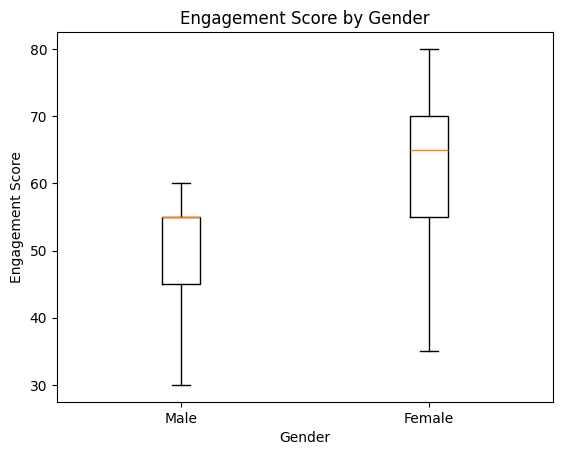

In [94]:
### Boxplot (EngagementScore vs Gender)

import matplotlib.pyplot as plt


male_scores = df_imputed[df_imputed['Gender'] == 'Male']['EngagementScore']
female_scores = df_imputed[df_imputed['Gender'] == 'Female']['EngagementScore']

plt.boxplot([male_scores, female_scores], tick_labels=['Male', 'Female'])
plt.xlabel('Gender')
plt.ylabel('Engagement Score')
plt.title('Engagement Score by Gender')
plt.show()

**Key Insights**:
- Female has higher Engagement Score than Male, seen by the higher median, Q3 and max value 
- Female has higher variablity with IQR spread
- Both do not have any outliers

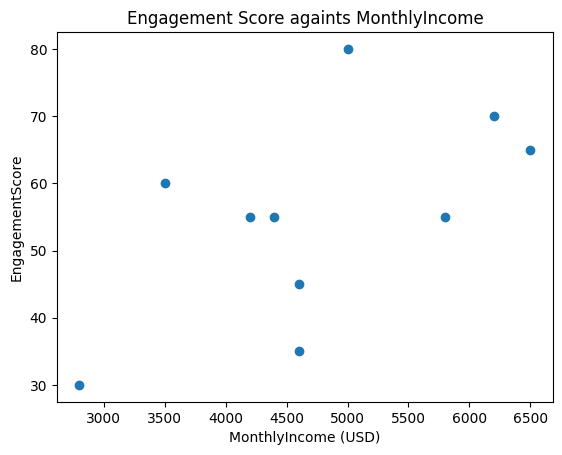

In [95]:
### Scatter plot (MonthlyIncome vs EngagementScore)

x = df_imputed['MonthlyIncome (USD)']
y = df_imputed['EngagementScore']

plt.scatter(x, y)
plt.xlabel('MonthlyIncome (USD)')
plt.ylabel('EngagementScore')
plt.title('Engagement Score againts MonthlyIncome')
plt.show()

**Key Insights**:
- It can be seen that as monthly income increases, the engagement score tend to increase as well. 

# 3 Machine Learning Model

## 3.1 K-means Clustering
- Perform K-means clustering to segment customers based on their engagement and income behavior. Use the Elbow Method to determine the optimal number of clusters.
- Interpret the centroids and discuss what each cluster represents in terms of customer behavior.
- Discuss how K-means could fail in certain situations and suggest alternative algorithms if needed (e.g., DBSCAN, Hierarchical Clustering).

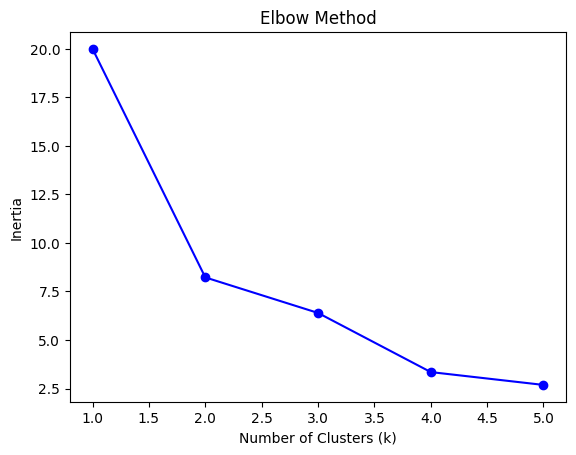

In [96]:
# Select only income and engagement score
cluster_data = df_imputed[['MonthlyIncome (USD)', 'EngagementScore']].copy()

# Scale the numerical variables
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

# Elbow method to identify the optimal number of elbow 
inertias = []
K_range = range(1, 6)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Key Insights**:
- The most optimal cluster seemed to be 2 since it is where the graph bends sharply
- We select K=2 as the optimal number of cluster

In [97]:
## Fit the model
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_data['Cluster'] = kmeans.fit_predict(cluster_scaled)

## Obtain centroid 
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler_cluster.inverse_transform(centroids_scaled) 

print("Centroids (MonthlyIncome, EngagementScore):")
for i, centroid in enumerate(centroids_original):
    print(f"Cluster {i}: Income=${centroid[0]:.2f}, Engagement={centroid[1]:.2f}")

Centroids (MonthlyIncome, EngagementScore):
Cluster 0: Income=$5875.00, Engagement=67.50
Cluster 1: Income=$4016.67, Engagement=46.67


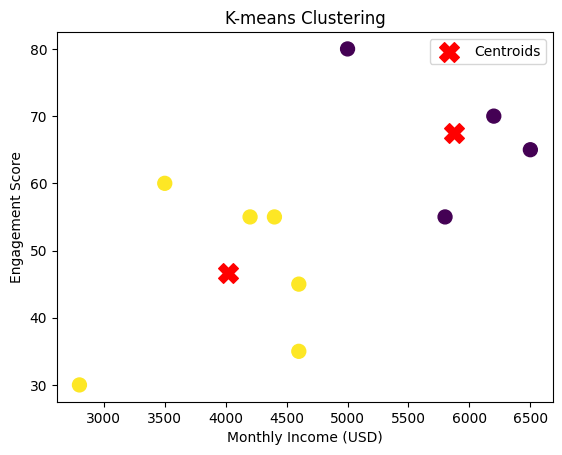

In [98]:

plt.scatter(cluster_data['MonthlyIncome (USD)'], cluster_data['EngagementScore'], 
            c=cluster_data['Cluster'], cmap='viridis', s=100)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Monthly Income (USD)')
plt.ylabel('Engagement Score')
plt.title('K-means Clustering')
plt.legend()
plt.show()

**Key Insights**:
- Two clusters are present:
    1. Higher income with higher engagement score (purple)
        - Income range: ~$5,000-$6,500
        - Engagement scores: 60-80
    2. Lower income with lower engagement score (yellow)
        - Income range: ~$2,800-$4,600
        - Engagement scores: 30-55

- K-means limitations:
    - Binary split may oversimplify client diversity
    - Sensitive to outliers in small datasets (n=10)
    - Better alternatives: DBSCAN (identifies noise/outliers)

## 3.2 Cluster Evaluation
- Calculate the Silhouette Score for your clustering result. Explain what the Silhouette Score measures and interpret the result.

In [99]:
from sklearn.metrics import silhouette_score, silhouette_samples

# Calculate overall silhouette score
silhouette_avg = silhouette_score(cluster_scaled, cluster_data['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Calculate per-sample silhouette scores
sample_silhouette_values = silhouette_samples(cluster_scaled, cluster_data['Cluster'])

# Add to dataframe for analysis
cluster_data['Silhouette_Score'] = sample_silhouette_values

print("\nSilhouette Scores by Cluster:")
print(cluster_data.groupby('Cluster')['Silhouette_Score'].agg(['mean', 'min', 'max']))

Silhouette Score: 0.450

Silhouette Scores by Cluster:
             mean       min       max
Cluster                              
0        0.477630  0.296297  0.641860
1        0.432338  0.382756  0.474772


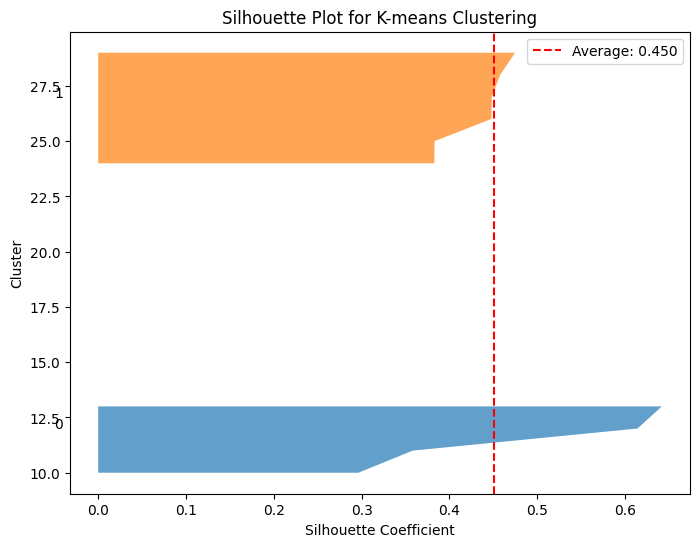

In [100]:
# Visualize silhouette scores
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

y_lower = 10
for i in range(optimal_k):
    cluster_silhouette_values = sample_silhouette_values[cluster_data['Cluster'] == i]
    cluster_silhouette_values.sort()

    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Average: {silhouette_avg:.3f}')
ax.set_title('Silhouette Plot for K-means Clustering')
ax.legend()
plt.show()

Silhouette Score measures how well-defined and separated the clusters are, ranging from -1 to 1:
- 1 means tight and well-seperated clusters
- 0 suggests overlapping clusters
- -1 indicates points might be in the wrong cluster

The obtained Silhouette Score is 0.450
- Clusters are reasonably separated but have some overlap
- May consider alternative clustering algorithms (DBSCAN etc)

## 3.3 Clustering Interpretation:
- Based on the clustering, suggest business strategies for each customer segment (e.g., target segments for high-value promotions, discounts for low-income groups, etc.).

1. Cluster 0: Premium Engaged Segment (High income and high engagement)
    - Characteristics:
      - Centroid: $5,875 income / 67.5 engagement
      - Income: $5,000-$6,500 | Engagement: 60-80
      - Higher silhouette scores (0.30-0.64) = well-defined group
    - Business Strategies:
      - Establish VIP Loyalty Program with exclusive rewards, early product access, priority support
      - Approch of premium Upselling with high-margin services and personalised packages

2. Cluster 1: Growth Opportunity Segment (Low income and low engagement)
    - Characteristics:
      - Centroid: $4,017 income / 46.67 engagement
      - Income: $2,800-$4,600 | Engagement: 30-55
      - More uniform silhouette scores (0.38-0.47) = moderate cohesion
    - Business Strategies:
      - More engagements such as emails, messages and success stories
      - Tiered pricing to slowly move customers to Cluster 0 (Premium)